In [35]:
# standard libraries
import os
import sys
import copy
import math
import re
from pathlib import Path

# data manipulation
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# statistics & transformations
from scipy import stats
from scipy.stats import boxcox, yeojohnson, probplot
from scipy.stats.mstats import winsorize
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.outliers_influence import variance_inflation_factor

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    MinMaxScaler, PowerTransformer, StandardScaler,
    OneHotEncoder, LabelEncoder
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.feature_selection import mutual_info_regression

# notebook display
from IPython.display import display, HTML

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 250)

SEED = 42

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / ".git").exists())
DATA_DIR = REPO_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"


In [36]:
data = pd.read_parquet(PROCESSED_DIR / "cleaned_model_ready.parquet")


# 4. Train–Test Split and Baseline Preprocessing

### 4.1 Train / test / valid split

In [37]:
# separate features and target
target = 'price'
X = data.drop(columns=[target])
y = data[target]
y_strat = pd.qcut(y, q=5, labels=False, duplicates='drop') # create price bins for stratification


# train+valid vs test
X_train_valid, X_test, y_train_valid, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y_strat, random_state=42)

# split train_valid into train and valid, re-bin target again on the subset:
y_train_valid_strat = pd.qcut(y_train_valid, q=5, labels=False, duplicates='drop')

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_valid, y_train_valid, test_size=0.2, stratify=y_train_valid_strat, random_state=42)


print('X train size: ' + str(X_train.shape[0]))
print('X valid size: ' + str(X_valid.shape[0]))
print('X train_valid size: ' + str(X_train_valid.shape[0]))
print('X test (holdout) size: ' + str(X_test.shape[0]))
print('\n')
print('Y train size: ' + str(y_train.shape[0]))
print('Y valid size: ' + str(y_valid.shape[0]))
print('Y train_valid size: ' + str(y_train_valid.shape[0]))
print('Y test (holdout) size: ' + str(y_test.shape[0]))
print('\n')
print('Total data size: ' + str(data.shape[0]))
if data.shape[0] == (y_train.shape[0] + y_valid.shape[0] +y_test.shape[0]):
    print('Sample sizes are correct')

X train size: 2584
X valid size: 646
X train_valid size: 3230
X test (holdout) size: 808


Y train size: 2584
Y valid size: 646
Y train_valid size: 3230
Y test (holdout) size: 808


Total data size: 4038
Sample sizes are correct


In [38]:
categorical = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
print(f'Number of categorical variables: {len(categorical)}')

numerical = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f'Number of numeric variables: {len(numerical)}')

levels_discrete = 30
discrete = [var for var in numerical if X_train[var].nunique() < levels_discrete]
print(f'Discrete variables: {discrete}')

continuous = [var for var in numerical if var not in discrete]
print(f'Continuous variables: {continuous}')



Number of categorical variables: 12
Number of numeric variables: 16
Discrete variables: ['balcony', 'energy_performance_certificate', 'furnished', 'cellar', 'parking', 'garage', 'loggia', 'basin_area', 'floor_number', 'total_floors']
Continuous variables: ['usable_area', 'floorage', 'terrace', 'garden_area', 'final_building_approval_year', 'square_meters']


C:\Users\necha\AppData\Local\Temp\ipykernel_22628\3221410169.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical = X_train.select_dtypes(include=['object', 'category']).columns.tolist()


### 4.2 Missing values handling

Impute categorical missing values with 'Missing'

In [39]:
for df in (X_train, X_valid, X_test):
    df[categorical] = df[categorical].fillna('Missing')


For numeric features we will impute values but also create flagged columns (name_NA) since several features might have a non-random missingness.

- continuous variables will be imputed with median values
- discrete variables will be imputed with mode value

In [40]:
def get_impute_values(df, method='median', cols=None):
    """
    Compute imputation values (median, mean, or mode) for specified columns.
    """
    df = df.copy()
    impute_vals = {}

    if cols is None:
        cols = df.select_dtypes(include='number').columns

    for col in cols:
        if df[col].isna().sum() > 0:
            if method == 'median':
                impute_vals[col] = df[col].median()
            elif method == 'mean':
                impute_vals[col] = df[col].mean()
            elif method == 'mode':
                impute_vals[col] = df[col].mode()[0]
            else:
                raise ValueError("Unsupported method")
    return impute_vals


In [41]:
# adding new_na_cols return, so the new flagged _NA columns can be easily added to numerical and discrete lists

def apply_impute_values(df, impute_dict, add_missing_flags=False):
    df = df.copy()
    new_na_cols = []

    for col, val in impute_dict.items():
        if add_missing_flags:
            na_col = col + "_NA"
            df[na_col] = df[col].isna().astype(int)
            new_na_cols.append(na_col)
        df[col] = df[col].fillna(val)

    return df, new_na_cols


In [42]:
# get impute values from X_train only. continuous will use median method and discrete - mode.
cont_impute_vals = get_impute_values(X_train, method='median', cols=continuous)
disc_impute_vals = get_impute_values(X_train, method='mode', cols=discrete)

# merge 2 dictionaries with discrete and continuous imputation values
all_impute_vals = {**cont_impute_vals, **disc_impute_vals}

# impute values into train, valid and test sets, create train_na_cols list of new _NA columns
X_train, train_na_cols = apply_impute_values(X_train, all_impute_vals, add_missing_flags=True)
X_valid, _ = apply_impute_values(X_valid, all_impute_vals, add_missing_flags=True)
X_test, _  = apply_impute_values(X_test, all_impute_vals, add_missing_flags=True)

# append new binary NA flags to discrete and numerical list
discrete.extend(train_na_cols)
numerical.extend(train_na_cols)

### 4.3 Feature Generation and encoding

##### 4.3.1 Feature generation

Add building_age variable - might be more informative than 'final_building_approval_year'

Relative floor info - identifying if it's a top or ground floor, might be informative.
We would assume that the ground floor can be both 0 and 1, since there're suspiciously few 0 floors in the dataset (only 15)


In [43]:
for df in (X_train, X_valid, X_test):
    # total area
    area_features = ['square_meters', 'balcony', 'terrace', 'cellar', 'loggia', 'basin_area']
    df['total_area']    = ( df[area_features]
                            .sum(axis=1) )

    # top / ground‐floor flags
    df['is_top_floor']     = (df['floor_number']==df['total_floors']).astype(int)
    df['is_ground_floor']  = ((df['floor_number']==1) | (df['floor_number']==0)).astype(int)

    # building age - 2024 is a data collection year so we use it as a reference
    df['building_age']     = 2024 - df['final_building_approval_year']
    df['building_age'] = df['building_age'].clip(lower=0)



In [44]:
continuous += ['building_age','total_area']
discrete   += ['is_top_floor','is_ground_floor']
numerical  += ['building_age','total_area','is_top_floor','is_ground_floor']

print('numerical', numerical)
print('continuous', continuous)
print('discrete:', discrete)
print('categorical:', categorical)

numerical ['usable_area', 'floorage', 'balcony', 'energy_performance_certificate', 'furnished', 'terrace', 'cellar', 'parking', 'garden_area', 'garage', 'loggia', 'final_building_approval_year', 'basin_area', 'floor_number', 'total_floors', 'square_meters', 'usable_area_NA', 'floorage_NA', 'final_building_approval_year_NA', 'floor_number_NA', 'total_floors_NA', 'building_age', 'total_area', 'is_top_floor', 'is_ground_floor']
continuous ['usable_area', 'floorage', 'terrace', 'garden_area', 'final_building_approval_year', 'square_meters', 'building_age', 'total_area']
discrete: ['balcony', 'energy_performance_certificate', 'furnished', 'cellar', 'parking', 'garage', 'loggia', 'basin_area', 'floor_number', 'total_floors', 'usable_area_NA', 'floorage_NA', 'final_building_approval_year_NA', 'floor_number_NA', 'total_floors_NA', 'is_top_floor', 'is_ground_floor']
categorical: ['building', 'property_status', 'property_location', 'water', 'heating', 'gas', 'energy_performance_rating', 'waste',

##### 4.3.2 Encoding ordinal variables

Encoding the ordinal variable energy_performance_rating

In [45]:
rating_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}

for df in [X_train, X_valid, X_test]:
    df['energy_performance_rating_numeric'] = (
        df['energy_performance_rating']
        .map(rating_map)
        .fillna(8)  # apply directly before casting
        .astype(int)
    )

In [46]:
categorical.remove('energy_performance_rating')
numerical.append('energy_performance_rating_numeric')
discrete.append('energy_performance_rating_numeric')

In [47]:
# save full datasets and lists, they will be used for tree-based models
X_train_full = X_train.copy()
X_valid_full = X_valid.copy()
X_test_full  = X_test.copy()

all_cols_full = numerical + categorical

X_train_full = X_train_full[all_cols_full]
X_valid_full = X_valid_full[all_cols_full]
X_test_full  = X_test_full[all_cols_full]

categorical_full = categorical
numerical_full = numerical
discrete_full = discrete
continuous_full = continuous

saving full feature set before linear model filtering. tree models will use this directly

# 5. Feature selection and model preparation

### 5.1 Target analysis and transformation

In [48]:
def plot_distribution(y, title="Original"):
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    sns.histplot(y, kde=True, ax=ax[0])
    ax[0].set_title(f'{title} - Histogram + KDE')
    sns.boxplot(y=y, ax=ax[1])
    ax[1].set_title(f'{title} - Boxplot')
    qqplot(y, line='s', ax=ax[2])
    ax[2].set_title(f'{title} - QQ Plot')
    plt.tight_layout()
    plt.show()

def transform_target_explorer(y): #, winsorize=False, winsorize_quantile=0.01
    """
    Visualize different types of transformations on the target variable.
    """
    print(f"\n Original target distribution:")
    plot_distribution(y, 'Original')

    positive = (y > 0).all()
    # log Transform
    if positive:
        y_log = np.log(y)
        print(f"\n Log-transformed target:")
        plot_distribution(y_log, 'Log')

    # box-Cox
    if positive:
        y_boxcox, lam_boxcox = boxcox(y)
        print(f"\n Box-Cox (λ={lam_boxcox:.3f}):")
        plot_distribution(y_boxcox, f'Box-Cox (λ={lam_boxcox:.3f})')

    # yeo-Johnson
    pt = PowerTransformer(method='yeo-johnson')
    y_yj = pt.fit_transform(y.values.reshape(-1, 1)).flatten()
    lam_yj = pt.lambdas_[0]
    print(f"\n Yeo-Johnson (λ={lam_yj:.3f}):")
    plot_distribution(y_yj, f'Yeo-Johnson (λ={lam_yj:.3f})')


 Original target distribution:


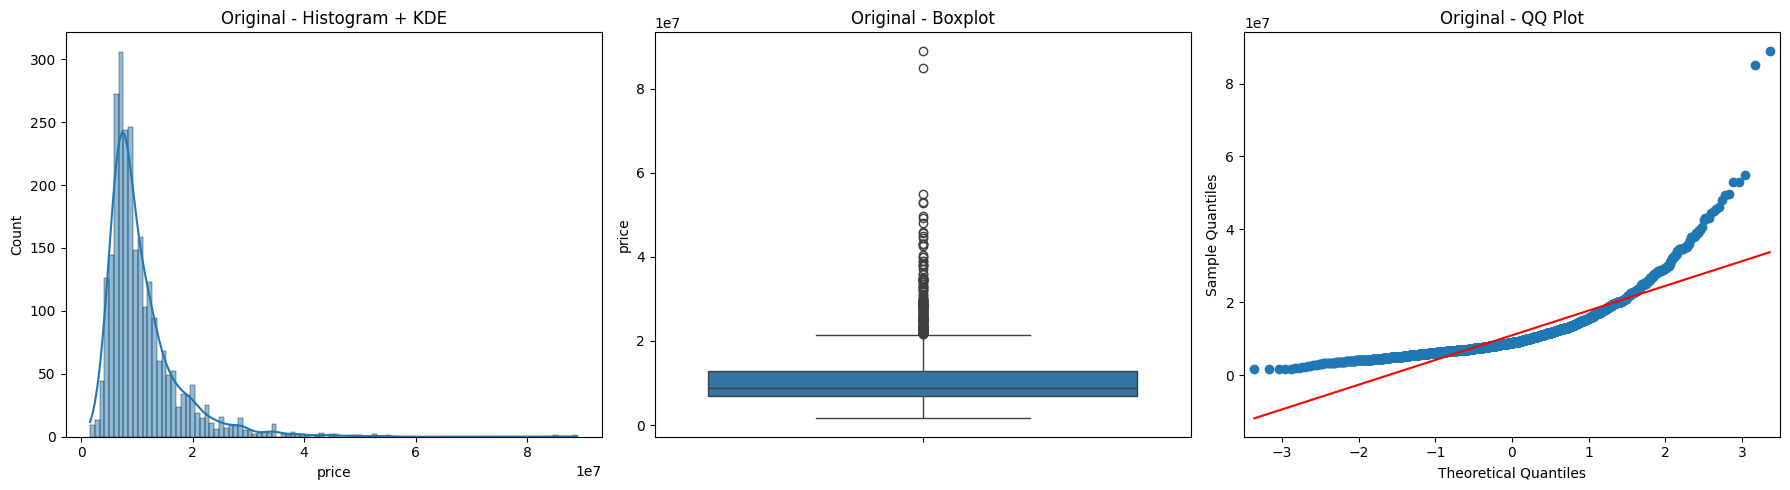


 Log-transformed target:


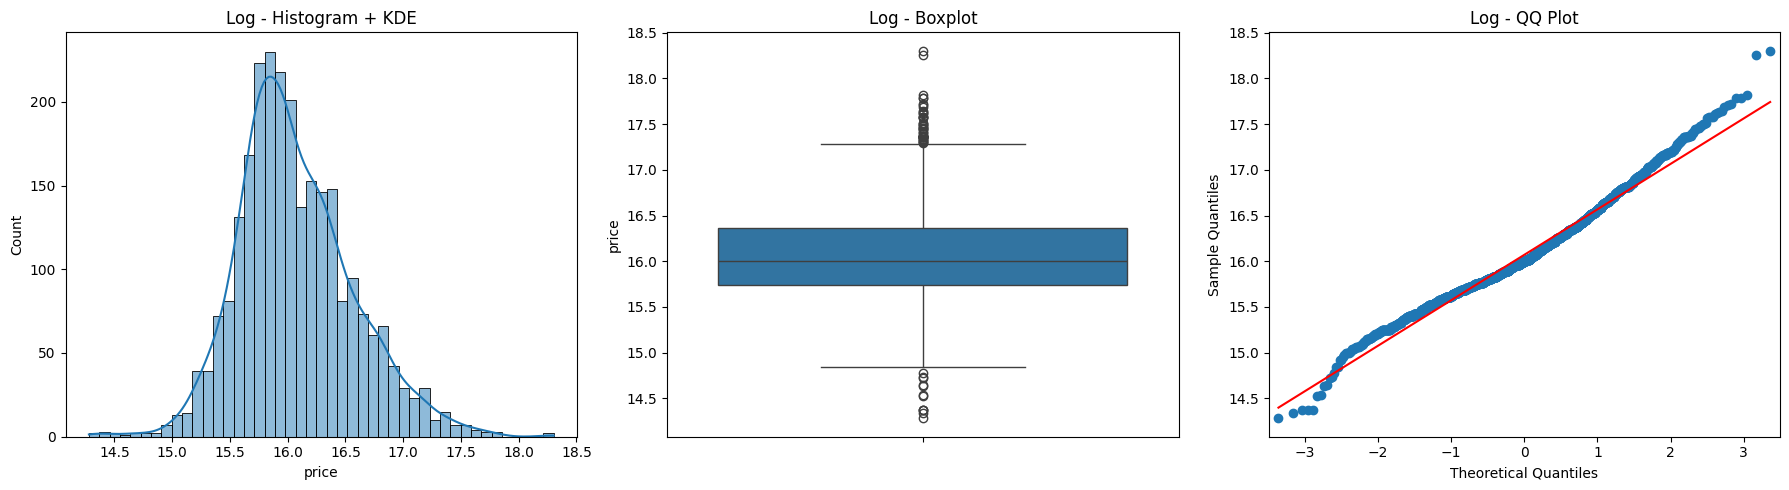


 Box-Cox (λ=-0.273):


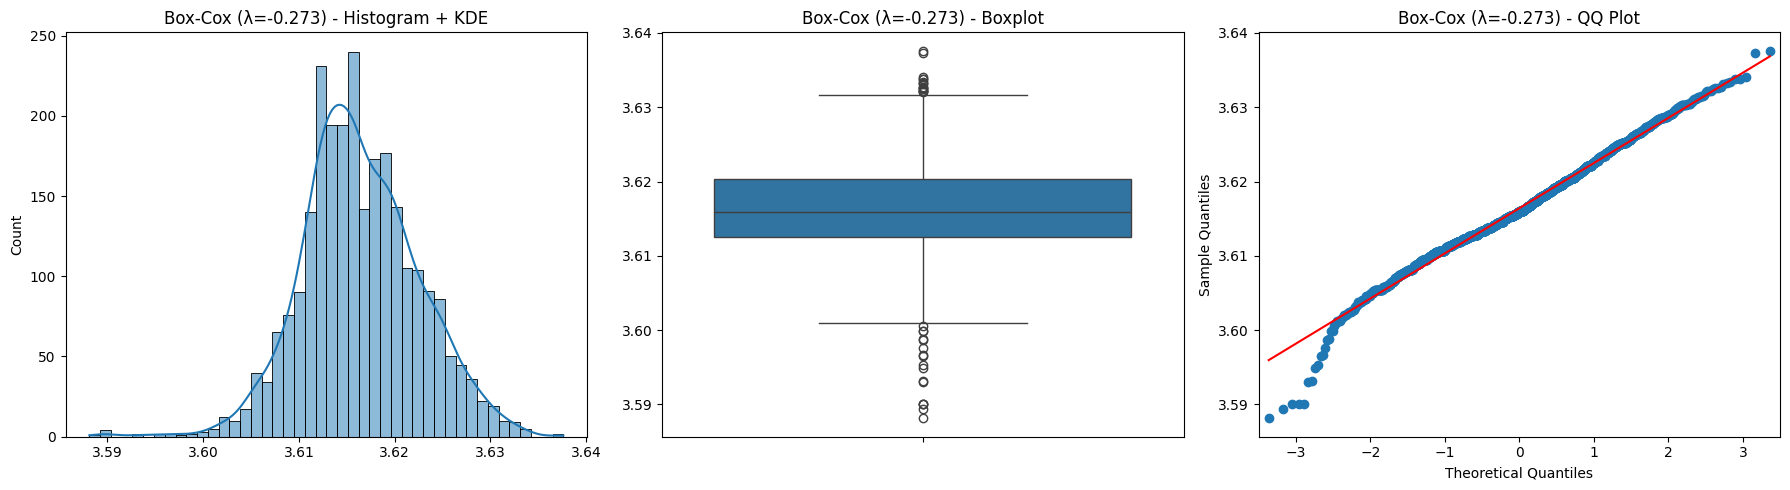


 Yeo-Johnson (λ=-0.273):


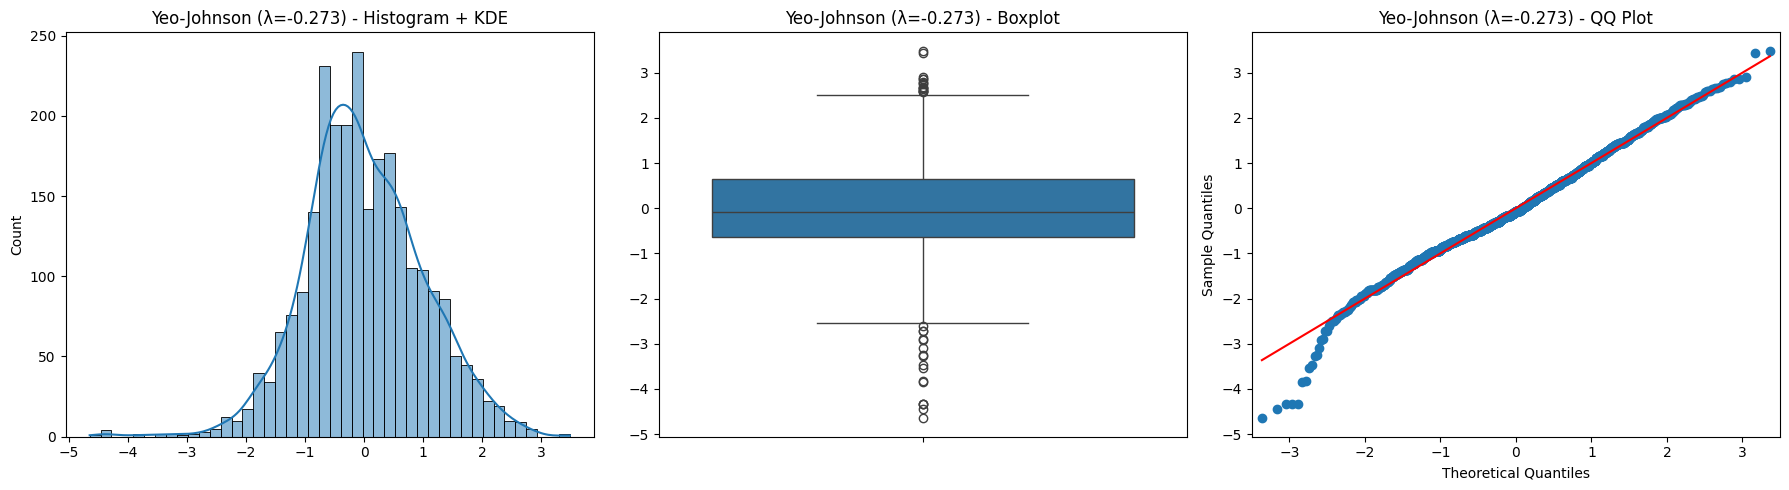

In [49]:
transform_target_explorer(y_train)

The log transformation substantially reduced skewness and improved normality in the Q-Q plot better than other methods, so it was selected for modeling.

We will log transform the target so models will predict log(price), evaluation will be done on log scale or exponentiated predictions

In [50]:
y_train = np.log(y_train)
y_valid = np.log(y_valid)
y_test = np.log(y_test)

### 5.2 Linear Model Preprocessing

##### 5.2.1 Basic feature filtering - low variance

Low-variance features contribute little to linear models and may add noise without predictive value. Still, we won't drop them automatically. the final call should be based on what the feature actually represents.

In [51]:
def identify_low_variance_features(df, continuous_vars, variance_threshold=0.01):
    """
    Identify continuous features with variance below the given threshold.
    """

    # normalize to [0, 1] to make variances comparable
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(df[continuous_vars])
    scaled_df = pd.DataFrame(scaled, columns=continuous_vars)

    # compute variances
    variances = scaled_df.var().sort_values()

    # identify low-variance features
    low_variance_features = variances[variances <= variance_threshold].index.tolist()

    if low_variance_features:
        print(f"\n{len(low_variance_features)} low-variance features (threshold={variance_threshold}):")
        for var in low_variance_features:
            print(f"{var}: {variances[var]:.6f}")
    else:
        print("No low-variance features found.")

    return low_variance_features, variances

In [52]:
low_var_features, variances = identify_low_variance_features(X_train, continuous_vars=continuous, variance_threshold=0.01)


6 low-variance features (threshold=0.01):
garden_area: 0.001063
terrace: 0.004742
floorage: 0.005456
usable_area: 0.005828
square_meters: 0.006187
total_area: 0.008889


Those features might still be important but we'll consider dropping them in a feature selection step

##### 5.2.2 High correlation



Highly correlated predictors destabilize linear model estimates. tree models handle this on their own.

In [53]:
def find_highly_correlated_features(df, feature_list, target_col=None, correlation_threshold=0.9, exclude_na_flags=True, plot=True):
    """
    Identify pairs of features with high Pearson correlation.
    """

    features = feature_list.copy()
    if exclude_na_flags:
        features = [f for f in features if '_NA' not in f]

    # compute correlation matrix
    corr_matrix = df[features].corr()


    if plot:
        plt.figure(figsize=(20, 15))
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
        cmap = sns.diverging_palette(230, 20, as_cmap=True)
        sns.heatmap(corr_matrix, mask=mask, cmap=cmap, vmax=1, center=0, annot=True,
                    fmt=".2f", square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
        plt.title("Feature Correlation Matrix", fontsize=18)
        plt.show()


    # unstack and filter correlations
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    high_corr_pairs = upper_tri.stack().reset_index()
    high_corr_pairs.columns = ['Feature1', 'Feature2', 'Correlation']
    high_corr_pairs['Correlation_abs'] = high_corr_pairs['Correlation'].abs()
    high_corr_df = high_corr_pairs[high_corr_pairs['Correlation_abs'] > correlation_threshold]
    high_corr_df = high_corr_df.sort_values('Correlation_abs', ascending=False)

    print(f"\n Found {len(high_corr_df)} pairs with correlation > {correlation_threshold}")
    return high_corr_df, corr_matrix

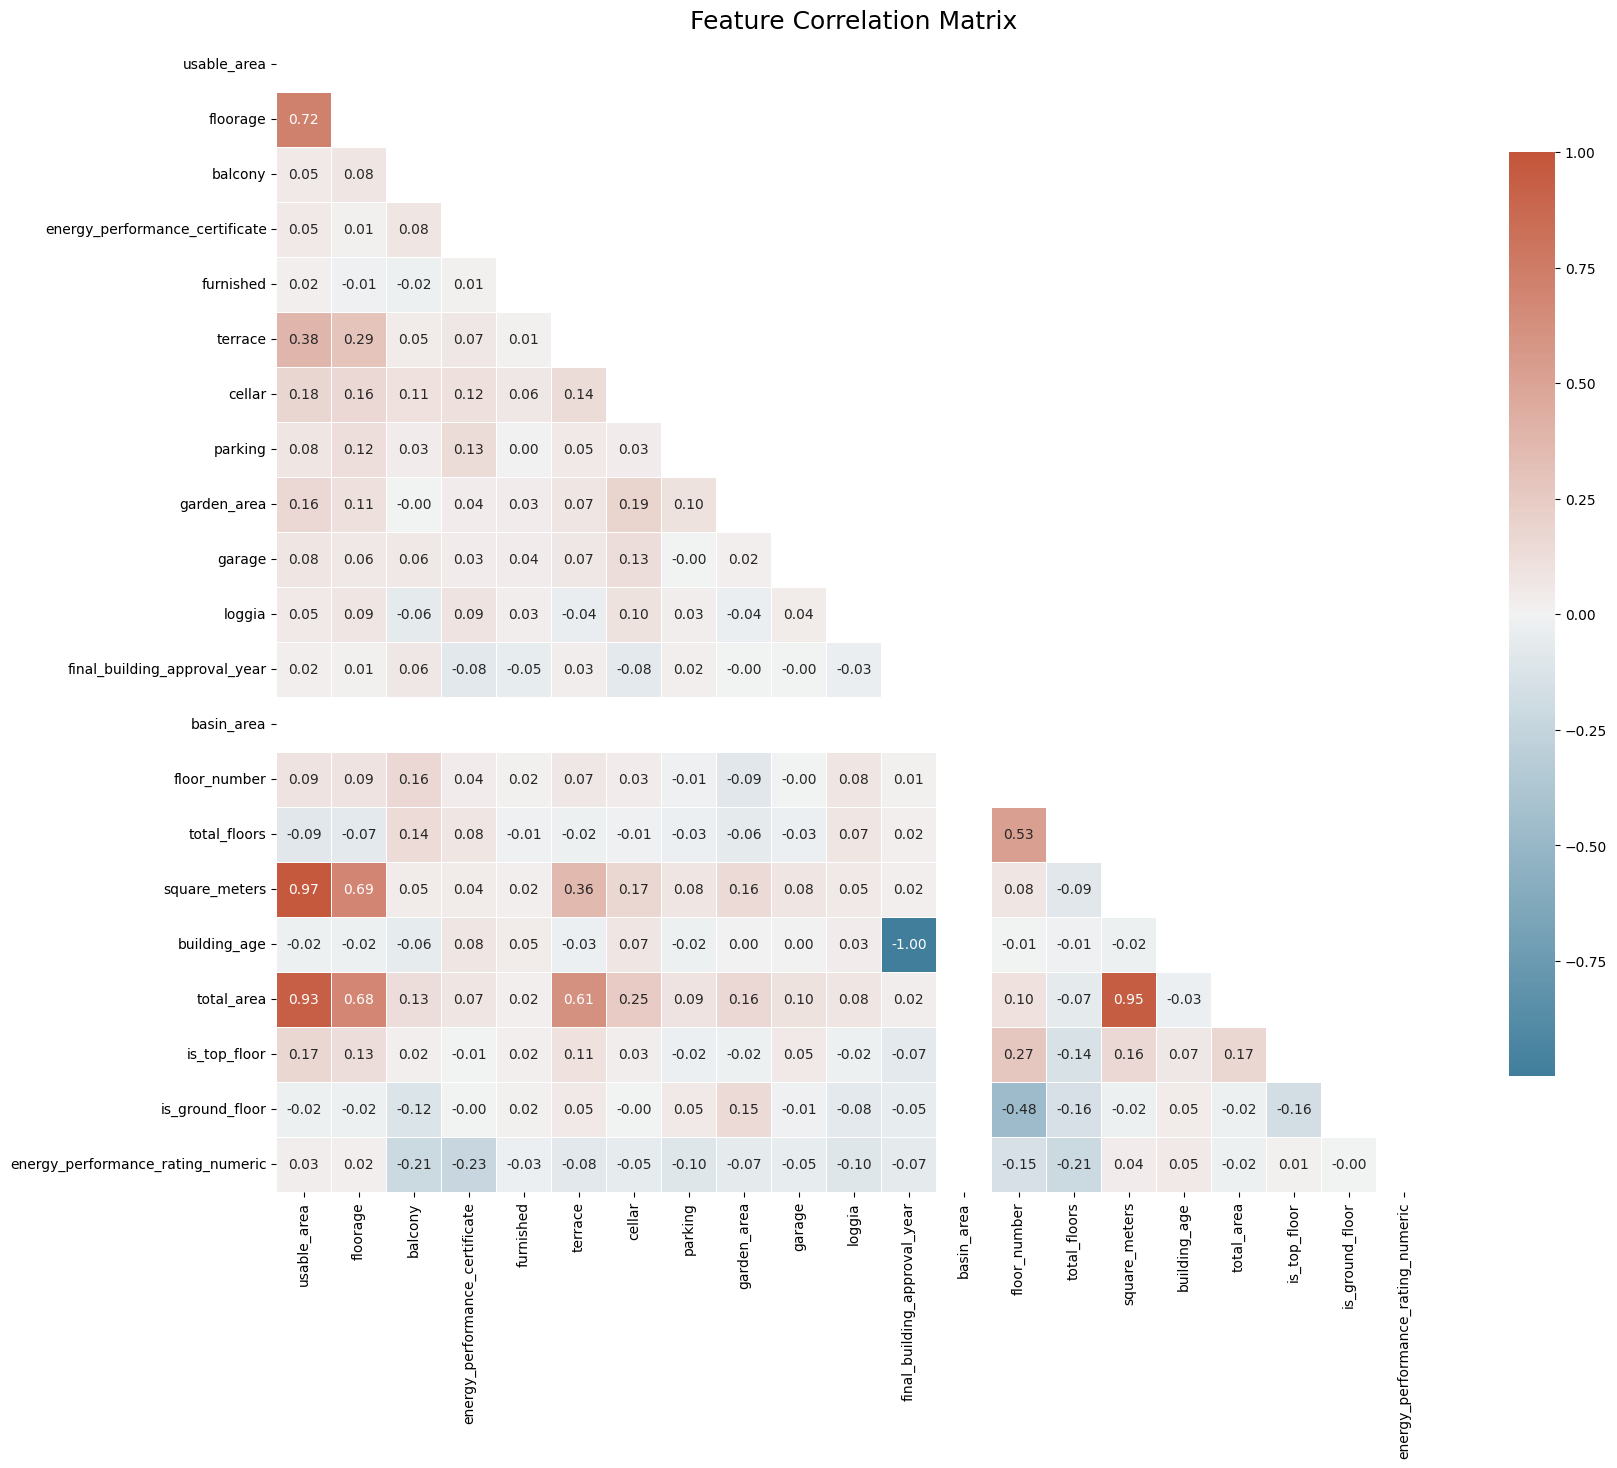


 Found 4 pairs with correlation > 0.9


,Feature1,Feature2,Correlation,Correlation_abs
247,final_building_approval_year,building_age,-0.999472,0.999472
15,usable_area,square_meters,0.969360,0.969360
332,square_meters,total_area,0.951839,0.951839
17,usable_area,total_area,0.931232,0.931232


In [54]:
high_corr_df, updated_corr_matrix = find_highly_correlated_features(
    df=X_train,
    feature_list=numerical,
    target_col='price',
    correlation_threshold=0.9,
    exclude_na_flags=True,
    plot=True
)

display(high_corr_df)


Looking at individual R² to decide which one to keep from each highly correlated pair. Lower R² = candidate to drop, but not automatic.

In [55]:
def select_features_by_correlation_and_r2(X, y, high_corr_df):
    """
    Automatically drop the lower-R² feature from highly correlated pairs.
    """
    to_drop = []
    for _, row in high_corr_df.iterrows():
        f1, f2 = row['Feature1'], row['Feature2']
        r2_f1 = r2_score(y, LinearRegression().fit(X[[f1]], y).predict(X[[f1]]))
        r2_f2 = r2_score(y, LinearRegression().fit(X[[f2]], y).predict(X[[f2]]))

        print(f"{f1}: R²={r2_f1:.4f}, {f2}: R²={r2_f2:.4f}")

        drop_feature = f1 if r2_f1 < r2_f2 else f2
        to_drop.append(drop_feature)
        print(f"dropping: {drop_feature}")

    return to_drop


In [56]:
features_to_remove = select_features_by_correlation_and_r2(X_train, y_train, high_corr_df)

final_building_approval_year: R²=0.0041, building_age: R²=0.0044
dropping: final_building_approval_year
usable_area: R²=0.5868, square_meters: R²=0.6447
dropping: usable_area
square_meters: R²=0.6447, total_area: R²=0.5892
dropping: total_area
usable_area: R²=0.5868, total_area: R²=0.5892
dropping: usable_area


Based on R2 score let's eliminate 2 features that have high correlation with another feature: total_area and final_building_approval_year

In [57]:
features_to_remove += ['final_building_approval_year_NA', 'usable_area_NA']

numerical = [x for x in numerical if x not in features_to_remove]
continuous = [x for x in continuous if x not in features_to_remove]
discrete = [x for x in discrete if x not in features_to_remove]

Categorical variables correlation

In EDA we've identified that there's high correlation between cadastral_area and district. Due to high cardinality of cadastral_area (more than 100 categories), and similar predictive power, we retain district and drop cadastral_area to reduce dimensionality and overfitting risk in linear models. Having that many coefficient estimates with very few observations per category might be unreliable.

Also we'll drop 'street' column due to even higher number of categories, and high number of categories would've had 1 or only a couple of observations.

In [58]:
features_to_remove = ['cadastral_area', 'street']
categorical = [x for x in categorical if x not in features_to_remove]

##### 5.2.3 Statistical feature selection

Results are used as guidance. MI has no natural scale and Lasso coefficients depend on the alpha path, so thresholds here are informational rather than objective. We look at the rankings and only consider dropping features with near-zero scores in both metrics.

In [59]:
X_num = X_train[numerical].copy()
y = y_train.copy()

# scale numerical features
x_scaler = StandardScaler()
X_scaled = pd.DataFrame(x_scaler.fit_transform(X_num), columns=X_num.columns)

# scale target
y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y.values.reshape(-1, 1)).ravel()

# compute mutual information
mi = mutual_info_regression(X_scaled, y_scaled, random_state=42)
mi_df = pd.DataFrame({'Feature': X_num.columns, 'Mutual_Info': mi})

# fit Lasso with cross-validation
lasso = LassoCV(cv=5, random_state=42).fit(X_scaled, y_scaled)
lasso_df = pd.DataFrame({
    'Feature': X_num.columns,
    'Lasso_Importance': np.abs(lasso.coef_)
})

# compute VIF
vif_scores = [variance_inflation_factor(X_scaled.values, i) for i in range(X_scaled.shape[1])]
vif_df = pd.DataFrame({'Feature': X_num.columns, 'VIF': vif_scores})

# combine results
num_df = mi_df.merge(lasso_df, on='Feature').merge(vif_df, on='Feature').set_index('Feature')

lasso_threshold = 0.01

# recommended drop if weak in both MI and Lasso
num_df['Recommended_Drop'] = (
    (num_df['Mutual_Info'] < 0.01) &
    (num_df['Lasso_Importance'] < lasso_threshold)
)

# vIF warning
num_df['High_VIF'] = num_df['VIF'] > 10

num_keep = num_df[~num_df['Recommended_Drop']].index.tolist()
num_drop = num_df[num_df['Recommended_Drop']].index.tolist()

print(num_df.sort_values(by='Mutual_Info', ascending=False))
print(f"\n Keep ({len(num_keep)}): {num_keep}")
print(f"\n Drop ({len(num_drop)}): {num_drop}")

if num_df['High_VIF'].any():
    print("\nHigh VIF warning:")
    print(num_df[num_df['High_VIF']].sort_values(by='VIF', ascending=False))
else:
    print("No features with high VIF detected.")


                                   Mutual_Info  Lasso_Importance       VIF  \
Feature                                                                      
square_meters                         0.801168          0.736490  2.179688   
floorage                              0.519986          0.079044  2.076745   
balcony                               0.078860          0.057543  1.118113   
total_floors                          0.073044          0.033829  1.835723   
terrace                               0.065589          0.008395  1.204109   
floor_number                          0.060158          0.005306  2.276021   
energy_performance_rating_numeric     0.059883          0.038892  1.497419   
garage                                0.038299          0.002290  1.031792   
cellar                                0.035522          0.010385  1.140045   
parking                               0.035315          0.004168  1.054813   
total_floors_NA                       0.025887          0.000464

d:\DS\Git\sreality_EDA\venv\Lib\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


'basin_area' were selected to drop.

'is_top_floor' has 0 Lasso importance and low MI, also it might be redundant, so we'll drop it as well.

In [60]:
features_to_remove = ['basin_area', 'is_top_floor']
continuous = [f for f in continuous if f not in features_to_remove]
numerical = [f for f in numerical if f not in features_to_remove]
discrete = [f for f in discrete if f not in features_to_remove]

##### 5.2.4 Standardization, power transformation, one-hot encoding

Standardization is applied because regularized linear models (Ridge, Lasso, ElasticNet) are sensitive to feature scale. Scaling will improve numerical stability. Power transformation (Yeo–Johnson) will be applied to skewed variables, will make data more Gaussian-like.

We'll have a different transformation approach to different types of numeric values. Transformation for binary features will be skipped, continuous and heavily skewed features will be both power transformed and standardized, ordinal discrete features only standardized.


In [61]:
# final feature set after previous filtering
selected_features = numerical + categorical
X_train = X_train[selected_features].copy()
X_valid = X_valid[selected_features].copy()
X_test  = X_test[selected_features].copy()


# identify binary features and other feature groups
binary = [col for col in discrete if X_train[col].nunique() == 2]
discrete = [col for col in discrete if col not in binary]
skewed_counts = ['balcony', 'cellar', 'parking', 'garage', 'loggia']
ordinal_discrete = ['floor_number', 'total_floors', 'energy_performance_rating_numeric']
continuous_real = [col for col in continuous if col not in skewed_counts]

# pipelines
continuous_pipeline = Pipeline([
    ('power', PowerTransformer(method='yeo-johnson')),
    ('scale', StandardScaler())
])

skewed_pipeline = Pipeline([
    ('power', PowerTransformer(method='yeo-johnson')),
    ('scale', StandardScaler())
])

ordinal_pipeline = Pipeline([
    ('scale', StandardScaler())
])

cat_pipeline = OneHotEncoder(
    drop='first',
    sparse_output=False,
    handle_unknown='ignore'
)

# columnTransformer
preprocessor = ColumnTransformer([
    ('cont', continuous_pipeline, continuous_real),
    ('skew', skewed_pipeline, skewed_counts),
    ('ord',  ordinal_pipeline, ordinal_discrete),
    ('bin',  'passthrough', binary),
    ('cat',  cat_pipeline, categorical)
])

# fit and transform
X_train_index = X_train.index
X_valid_index = X_valid.index
X_test_index  = X_test.index

X_train_transformed = preprocessor.fit_transform(X_train)
X_valid_transformed = preprocessor.transform(X_valid)
X_test_transformed  = preprocessor.transform(X_test)

# reconstruct feature names
ohe_features = preprocessor.named_transformers_['cat'] \
    .get_feature_names_out(categorical)

final_feature_names = (
    continuous_real +
    skewed_counts +
    ordinal_discrete +
    binary +
    list(ohe_features)
)

X_train = pd.DataFrame(X_train_transformed, columns=final_feature_names, index=X_train_index)
X_valid = pd.DataFrame(X_valid_transformed, columns=final_feature_names, index=X_valid_index)
X_test = pd.DataFrame(X_test_transformed, columns=final_feature_names, index=X_test_index)

In [62]:
X_train[ordinal_discrete].describe()

,floor_number,total_floors,energy_performance_rating_numeric
count,2.584000e+03,2.584000e+03,2.584000e+03
mean,-3.712201e-17,-4.743368e-17,1.058665e-16
std,1.000194e+00,1.000194e+00,1.000194e+00
min,-1.445100e+00,-1.908818e+00,-1.400646e+00
25%,-6.151993e-01,-4.454192e-01,-1.000992e+00
50%,-2.002489e-01,-4.454192e-01,-6.013376e-01
75%,6.296519e-01,2.862802e-01,9.972800e-01
max,6.024007e+00,6.139875e+00,1.396934e+00


##### 5.2.5 Regularized model comparison

Regularized models help control overfitting and handle multicollinearity. Comparing them to see if shrinking coefficients actually helps here.

In [63]:
alphas = np.logspace(-6, 4, 80)

models = {
    "Ridge": RidgeCV(alphas=alphas, cv=5),
    "Lasso": LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=42),
    "ElasticNet": ElasticNetCV(
        alphas=alphas,
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
        cv=5,
        max_iter=10000,
        random_state=42
    )
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    # validation performance
    y_valid_pred = model.predict(X_valid)
    r2_valid = r2_score(y_valid, y_valid_pred)

    # sparsity
    if hasattr(model, "coef_"):
        nonzero = np.sum(model.coef_ != 0)
    else:
        nonzero = len(X_train.columns)

    results.append({
        "Model": name,
        "Best Alpha": getattr(model, "alpha_", None),
        "Validation R2": r2_valid,
        "Non-zero Coefs": nonzero
    })

results_df = pd.DataFrame(results).sort_values("Validation R2", ascending=False)
print(results_df)


        Model  Best Alpha  Validation R2  Non-zero Coefs
0       Ridge    0.496824       0.832851              71
1       Lasso    0.000044       0.832308              69
2  ElasticNet    0.000059       0.832121              68


After comparing Ridge, Lasso and ElasticNet using cross-validation, Ridge achieved the highest validation R², indicating that retaining all features provides the most stable performance. Although Lasso identified a small number of zero-coefficient features, removing them slightly reduces Ridge performance. Therefore, the full feature set was retained for the final linear benchmark.

In [64]:
X_train_reduced = X_train
X_valid_reduced = X_valid
X_test_reduced = X_test

### 5.3 Tree-based models preparation

##### 5.3.1 Column name sanitization

LightGBM and XGBoost fail when column names contain special characters. Sanitizing to safe format.

In [65]:
SEED = 42
np.random.seed(SEED)

def build_sanitization_map(cols):
    mapping, used = {}, {}
    for i, col in enumerate(cols):
        base = re.sub(r"\W+", "_", str(col)).strip("_") or f"col_{i}"
        name, k = base, 1
        while name in used:
            name = f"{base}_{k}"
            k += 1
        used[name] = True
        mapping[col] = name
    return mapping

sanit_map = build_sanitization_map(list(X_train_full.columns))

def apply_map(df):
    return df.rename(columns=sanit_map)

X_train_full_s   = apply_map(X_train_full)
X_valid_full_s   = apply_map(X_valid_full)
X_test_full_s    = apply_map(X_test_full)

X_train_reduced_s = apply_map(X_train_reduced)
X_valid_reduced_s = apply_map(X_valid_reduced)
X_test_reduced_s  = apply_map(X_test_reduced)

##### 5.3.2 Label Encoding

Tree models can't work with string columns, label encoding converts categorical strings to integers.

In [66]:
label_encoders = {}

for col in categorical_full:
    if col in X_train_full_s.columns:
        le = LabelEncoder()
        all_vals = pd.concat([
            X_train_full_s[col],
            X_valid_full_s[col],
            X_test_full_s[col]
        ]).astype("string").fillna("NA")

        le.fit(all_vals)

        for df in [X_train_full_s, X_valid_full_s, X_test_full_s]:
            if col in df.columns:
                df[col] = le.transform(df[col].astype("string").fillna("NA"))

        label_encoders[col] = le

In [67]:
# save encoding artifacts so notebook 05 can load them without re-running 04
encoding_artifacts = {
    "sanit_map": sanit_map,
    "label_encoders": label_encoders,
    "categorical_full": categorical_full,
}
import joblib
joblib.dump(encoding_artifacts, PROCESSED_DIR / "encoding_artifacts.joblib")
print("encoding artifacts saved")

encoding artifacts saved


In [68]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

X_train_full_s.to_parquet(PROCESSED_DIR / "X_train_full_s.parquet")
X_valid_full_s.to_parquet(PROCESSED_DIR / "X_valid_full_s.parquet")
X_test_full_s.to_parquet(PROCESSED_DIR / "X_test_full_s.parquet")

X_train_reduced_s.to_parquet(PROCESSED_DIR / "X_train_reduced_s.parquet")
X_valid_reduced_s.to_parquet(PROCESSED_DIR / "X_valid_reduced_s.parquet")
X_test_reduced_s.to_parquet(PROCESSED_DIR / "X_test_reduced_s.parquet")

pd.Series(y_train).to_frame("target").to_parquet(PROCESSED_DIR / "y_train.parquet")
pd.Series(y_valid).to_frame("target").to_parquet(PROCESSED_DIR / "y_valid.parquet")
pd.Series(y_test).to_frame("target").to_parquet(PROCESSED_DIR / "y_test.parquet")